# LightGBM Model Development
### Notebook Done By: Anuf/Cliff

This notebook contains the development process for the LightGBM model. This notebook covers the process of developing, evaluating, and refining this model.

In [1]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Loading train/test data

base_path = '../../data/modelling/'

X_train = pd.read_csv(base_path + 'X_train.csv', index_col=0)
X_test = pd.read_csv(base_path + 'X_test.csv', index_col=0)
y_train = pd.read_csv(base_path + 'y_train.csv', index_col=0)['log_price']
y_test = pd.read_csv(base_path + 'y_test.csv', index_col=0)['log_price']

In [3]:
# Fitting the base model

model = lgb.LGBMRegressor(random_state=42)
model.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001063 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3076
[LightGBM] [Info] Number of data points in the train set: 8524, number of used features: 35
[LightGBM] [Info] Start training from score 13.326602


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [4]:
# Predicting values from test data with the base model

y_pred = model.predict(X_test)

In [5]:
# Reviewing evaluation metrics for the base model

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('MAE:', mae)
print('RMSE:', rmse)
print('R2:', r2)

MAE: 0.17989192697738207
RMSE: 0.2542055409368462
R2: 0.8306590604884684


The evaluation metrics suggest that the base LightGBM model is more accurate than both the base and tuned Random Forest model.

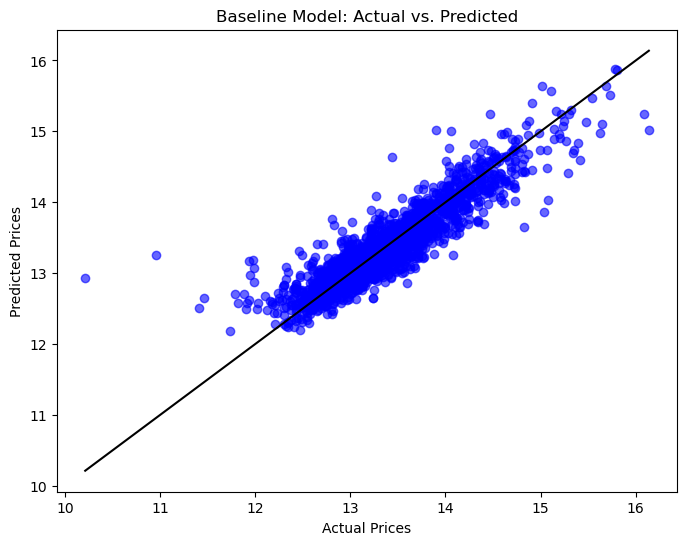

In [6]:
# Visualising how predicted values from the base model differ from actual values

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black')

plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Baseline Model: Actual vs. Predicted')
plt.show()

The chart above shows that the model is accurate in predicting lower/middle-ranged house prices, with some limitations as seen in the deviations when predicting higher-value property prices.

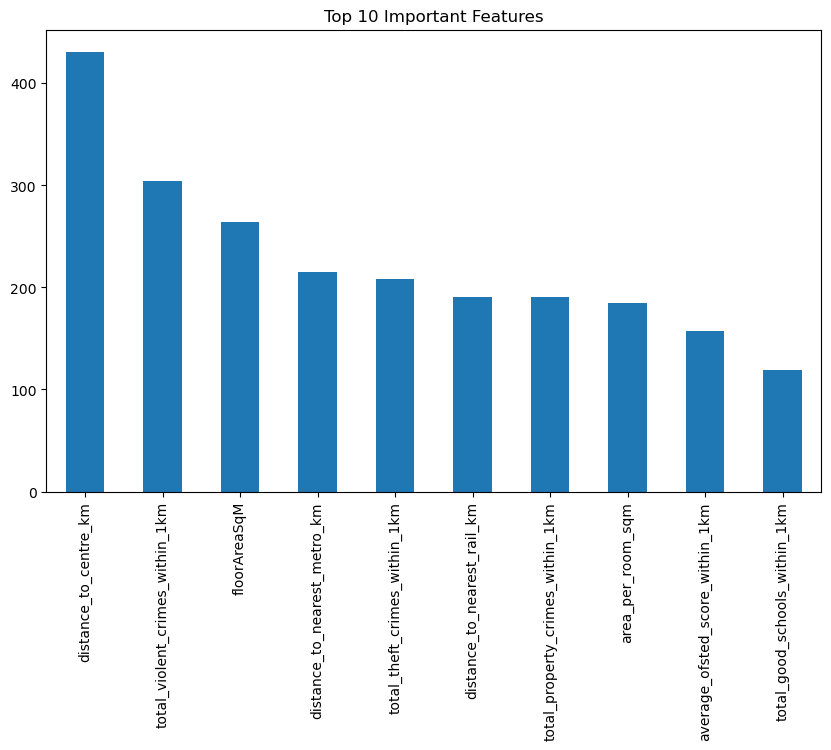

In [7]:
# Reviewing most important features in the base model

importance = pd.Series(model.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.head(10).plot(kind='bar')
plt.title('Top 10 Important Features')
plt.show()

The visualisation above shows that the most important features in this model mostly consist of structural features such as floor area, as well as spatial features such as distance to amenities and total crimes/good-schools within 1km.

Since this is only the base model, tuning the model may increase accuracy even more.

In [8]:
# Tuning the model and fitting it

model_tuned = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    min_child_samples=10,
    colsample_bytree=0.8,
    random_state=42
)

model_tuned.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000763 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3078
[LightGBM] [Info] Number of data points in the train set: 8524, number of used features: 36
[LightGBM] [Info] Start training from score 13.326602


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,10


In [9]:
# Predicting values from the test data with the tuned model

y_pred_tuned = model_tuned.predict(X_test)

In [10]:
# Reviewing evaluation metrics for the tuned model and comparing them to those of the base model

mae_base = mean_absolute_error(y_test, y_pred)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred))
r2_base = r2_score(y_test, y_pred)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print('=== Baseline Model ===')
print('MAE:', mae_base)
print('RMSE:', rmse_base)
print('R2:', r2_base)

print('=== Tuned Model ===')
print('MAE:', mae_tuned)
print('RMSE:', rmse_tuned)
print('R2:', r2_tuned)

=== Baseline Model ===
MAE: 0.17989192697738207
RMSE: 0.2542055409368462
R2: 0.8306590604884684
=== Tuned Model ===
MAE: 0.17381416882306716
RMSE: 0.24679497888445223
R2: 0.8403883530804744


After tuning the model multiple times, ideal parameters for this model have been found, as the evaluation metrics for the tuned model are an upgrade from the base model.

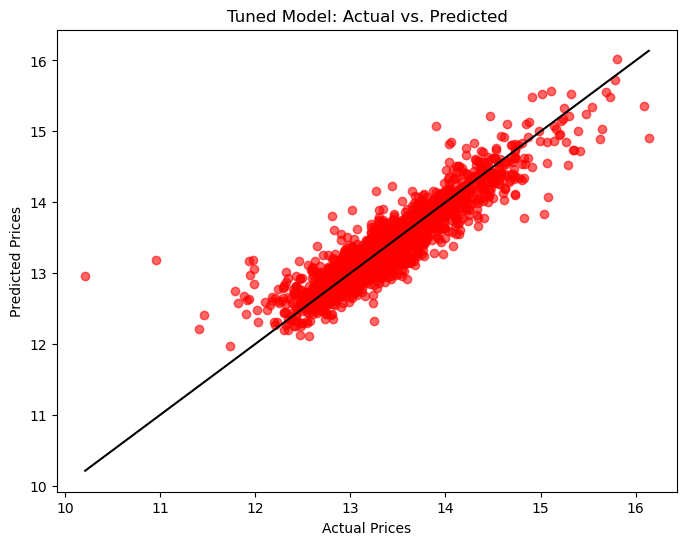

In [11]:
# Visualising how predicted values from the tuned model differ from actual values

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_tuned, alpha=0.6, color='red')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black')

plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Tuned Model: Actual vs. Predicted')
plt.show()

The chart above shows that the tuned model is accurate in predicting lower/middle-ranged house prices much like the base model, with also some limitations as seen in the deviations when predicting higher-value property prices. However, tuning the model slightly improved the accuracy in predicting higher-value property prices.

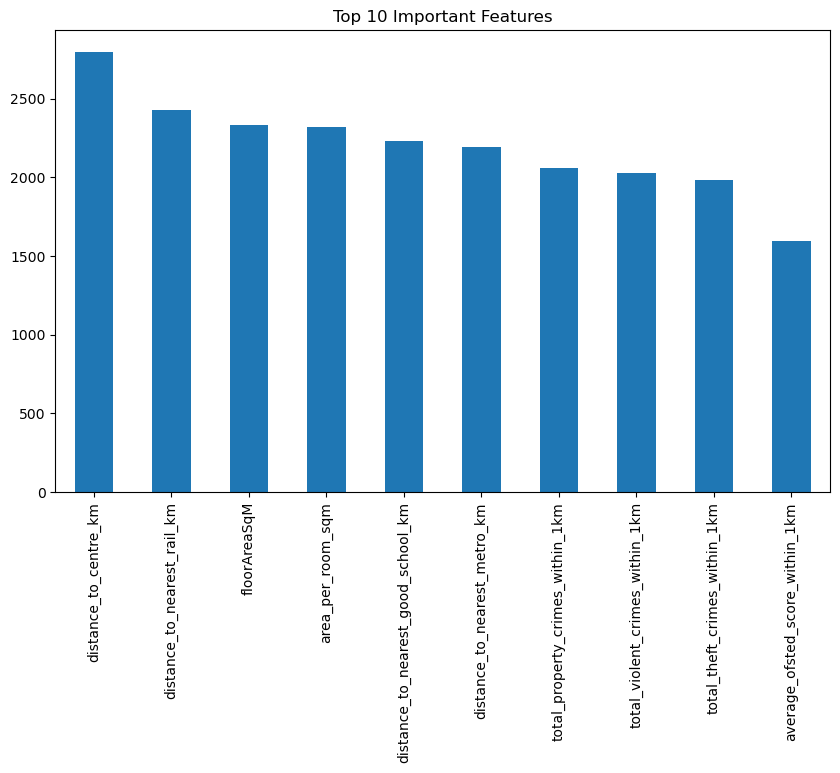

In [12]:
# Reviewing most important features in the tuned model

importance = pd.Series(model_tuned.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.head(10).plot(kind='bar')
plt.title('Top 10 Important Features')
plt.show()

The visualisation above shows that the most important features in this tuned model mostly consist of structural features such as floor area, as well as spatial features such as distance to amenities and total crimes/good-schools within 1km.

There is still one more model to test, which is the CatBoost model.

The next notebook is ```notebooks/modelling/catboost.ipynb```.